In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [3]:
df.head()

,society,price,sector,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,independent,15.50,sector 43,28233.0,5,6,3,3.0,Moderately Old,house,5490.00,1,1,1,1,0,0,76
1,trisara our homes 3,0.38,sohna road,6312.0,2,2,2,1.0,Relatively New,flat,602.00,0,0,0,0,0,0,0
2,sare green parc phase 3,0.70,sector 92,5279.0,3,2,2,4.0,Relatively New,flat,1325.00,0,0,0,0,0,0,56
3,emaar gurgaon greens,1.60,sector 102,9696.0,3,3,3,8.0,Relatively New,flat,1315.00,0,0,0,0,0,0,46
4,emaar mgf the palm drive,3.98,sector 66,18090.0,3,4,3+,2.0,Moderately Old,flat,2200.11,0,1,0,0,0,2,123


In [4]:
df.shape

(3554, 18)

In [5]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [6]:
train_df.head()

,price,sector,bedRoom,bathroom,balcony,floorNum,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,15.50,sector 43,5,6,3,3.0,Moderately Old,house,5490.00,1,1,1,1,0,0,76
1,0.38,sohna road,2,2,2,1.0,Relatively New,flat,602.00,0,0,0,0,0,0,0
2,0.70,sector 92,3,2,2,4.0,Relatively New,flat,1325.00,0,0,0,0,0,0,56
3,1.60,sector 102,3,3,3,8.0,Relatively New,flat,1315.00,0,0,0,0,0,0,46
4,3.98,sector 66,3,4,3+,2.0,Moderately Old,flat,2200.11,0,1,0,0,0,2,123


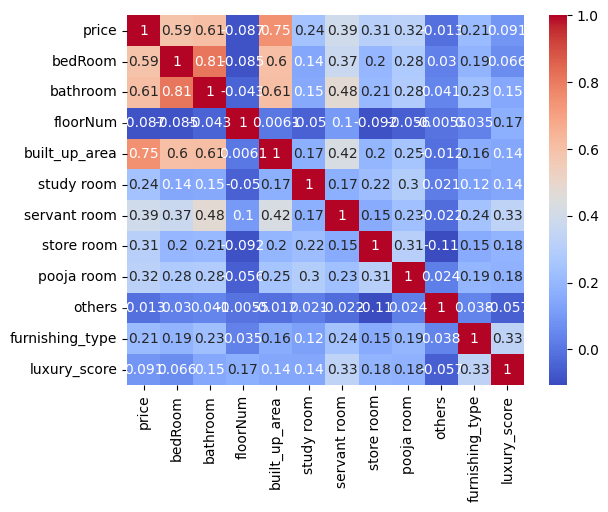

In [7]:
numeric_df = train_df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [8]:
train_df.select_dtypes(include='number').corr()['price'].sort_values(ascending=False)

price              1.000000
built_up_area      0.748508
bathroom           0.609701
bedRoom            0.591203
servant room       0.391497
pooja room         0.320021
store room         0.305797
study room         0.243128
furnishing_type    0.213406
luxury_score       0.091268
others            -0.013353
floorNum          -0.087394
Name: price, dtype: float64

In [9]:
train_df.head()

,price,sector,bedRoom,bathroom,balcony,floorNum,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,15.50,sector 43,5,6,3,3.0,Moderately Old,house,5490.00,1,1,1,1,0,0,76
1,0.38,sohna road,2,2,2,1.0,Relatively New,flat,602.00,0,0,0,0,0,0,0
2,0.70,sector 92,3,2,2,4.0,Relatively New,flat,1325.00,0,0,0,0,0,0,56
3,1.60,sector 102,3,3,3,8.0,Relatively New,flat,1315.00,0,0,0,0,0,0,46
4,3.98,sector 66,3,4,3+,2.0,Moderately Old,flat,2200.11,0,1,0,0,0,2,123


<Axes: xlabel='luxury_score'>

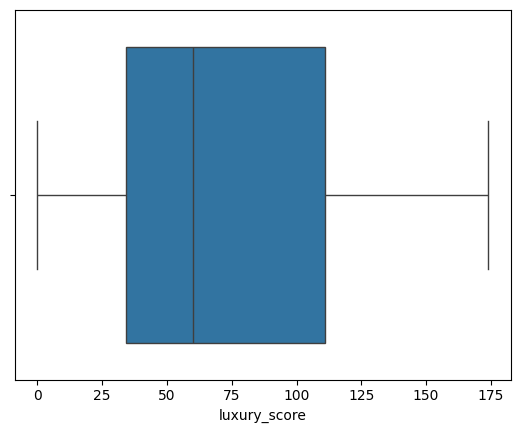

In [10]:
sns.boxplot(x = df['luxury_score'])

In [11]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None 

In [12]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [13]:
train_df.head()

,price,sector,bedRoom,bathroom,balcony,floorNum,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,15.50,sector 43,5,6,3,3.0,Moderately Old,house,5490.00,1,1,1,1,0,0,76,Medium
1,0.38,sohna road,2,2,2,1.0,Relatively New,flat,602.00,0,0,0,0,0,0,0,Low
2,0.70,sector 92,3,2,2,4.0,Relatively New,flat,1325.00,0,0,0,0,0,0,56,Medium
3,1.60,sector 102,3,3,3,8.0,Relatively New,flat,1315.00,0,0,0,0,0,0,46,Low
4,3.98,sector 66,3,4,3+,2.0,Moderately Old,flat,2200.11,0,1,0,0,0,2,123,Medium


<Axes: xlabel='floorNum'>

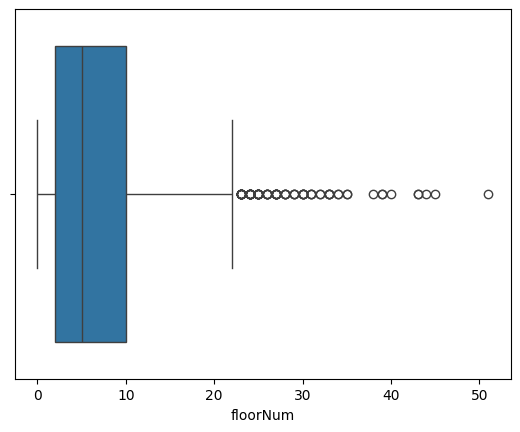

In [14]:
sns.boxplot(x = df['floorNum'])

In [15]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [16]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [17]:
train_df.head()

,price,sector,bedRoom,bathroom,balcony,floorNum,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,15.50,sector 43,5,6,3,3.0,Moderately Old,house,5490.00,1,1,1,1,0,0,76,Medium,Mid Floor
1,0.38,sohna road,2,2,2,1.0,Relatively New,flat,602.00,0,0,0,0,0,0,0,Low,Low Floor
2,0.70,sector 92,3,2,2,4.0,Relatively New,flat,1325.00,0,0,0,0,0,0,56,Medium,Mid Floor
3,1.60,sector 102,3,3,3,8.0,Relatively New,flat,1315.00,0,0,0,0,0,0,46,Low,Mid Floor
4,3.98,sector 66,3,4,3+,2.0,Moderately Old,flat,2200.11,0,1,0,0,0,2,123,Medium,Low Floor


In [18]:
train_df = train_df.drop(columns=['floorNum','luxury_score'])

In [19]:
train_df.head()

,price,sector,bedRoom,bathroom,balcony,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,15.50,sector 43,5,6,3,Moderately Old,house,5490.00,1,1,1,1,0,0,Medium,Mid Floor
1,0.38,sohna road,2,2,2,Relatively New,flat,602.00,0,0,0,0,0,0,Low,Low Floor
2,0.70,sector 92,3,2,2,Relatively New,flat,1325.00,0,0,0,0,0,0,Medium,Mid Floor
3,1.60,sector 102,3,3,3,Relatively New,flat,1315.00,0,0,0,0,0,0,Low,Mid Floor
4,3.98,sector 66,3,4,3+,Moderately Old,flat,2200.11,0,1,0,0,0,2,Medium,Low Floor


In [20]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37', 'sector 37c',
       'sector 37d', 'sector 38', 'sector 39', 'sector 4', 'sector 40',
       'sector 41', 'sector 43', 'sector 45', 'sector 46', 'sector 47',
       'sector 48', 'sector 49', 'sector 5', 'sector 50', 'sector 51',
       'sector 52', 'sector 53', 'sector 54', 'sector 55', 'sector

Technique 1 - Correlation Analysis

<Axes: >

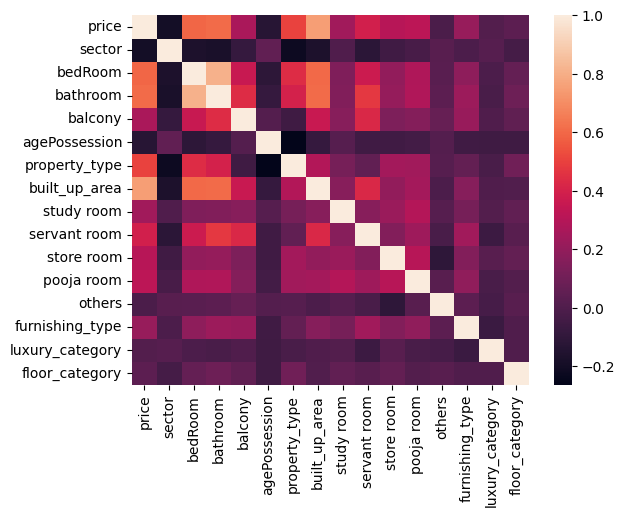

In [21]:
 sns.heatmap(data_label_encoded.corr())

In [22]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.198791
1,bedRoom,0.591203
2,bathroom,0.609701
3,balcony,0.269432
4,agePossession,-0.133417
5,property_type,0.503926
6,built_up_area,0.748508
7,study room,0.243128
8,servant room,0.391497
9,store room,0.305797


Technique 2 - Random Forest Feature Importance

In [23]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.653139
0,sector,0.106317
5,property_type,0.095051
2,bathroom,0.025053
1,bedRoom,0.024625
8,servant room,0.018994
4,agePossession,0.014524
3,balcony,0.013158
9,store room,0.010883
7,study room,0.007938


Technique 3 - Gradient Boosting Feature importances

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.678158
0,sector,0.102872
5,property_type,0.097568
1,bedRoom,0.037743
2,bathroom,0.037251
8,servant room,0.023162
9,store room,0.010316
4,agePossession,0.004512
7,study room,0.003090
3,balcony,0.002174


Technique 4 - Permutation Importance

In [25]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.711244
5,property_type,0.178062
0,sector,0.163812
8,servant room,0.015812
2,bathroom,0.009169
3,balcony,0.007263
4,agePossession,0.007153
7,study room,0.005362
1,bedRoom,0.002736
14,floor_category,0.001813


Technique 5 - LASSO

In [26]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.511174
5,property_type,0.714400
2,bathroom,0.278430
9,store room,0.198651
7,study room,0.175172
8,servant room,0.166453
12,furnishing_type,0.136955
10,pooja room,0.074819
13,luxury_category,0.050948
1,bedRoom,0.019292


Technique 6 - RFE

In [27]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.648926
0,sector,0.104236
5,property_type,0.100517
1,bedRoom,0.026121
2,bathroom,0.025951
8,servant room,0.020932
4,agePossession,0.015447
3,balcony,0.012334
7,study room,0.009048
12,furnishing_type,0.007712


Technique 7 - Linear Regression Weights

In [28]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.513802
5,property_type,0.714321
2,bathroom,0.285108
9,store room,0.202967
7,study room,0.183356
8,servant room,0.175828
12,furnishing_type,0.146056
10,pooja room,0.077785
13,luxury_category,0.062209
1,bedRoom,0.022069


In [30]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').set_index('feature')

In [31]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs
feature,,,,,,,
sector,-0.198791,0.106317,0.102872,0.163812,-0.050329,0.104236,-0.059192
bedRoom,0.591203,0.024625,0.037743,0.002736,0.019292,0.026121,0.022069
bathroom,0.609701,0.025053,0.037251,0.009169,0.278430,0.025951,0.285108
balcony,0.269432,0.013158,0.002174,0.007263,-0.044312,0.012334,-0.067275
agePossession,-0.133417,0.014524,0.004512,0.007153,-0.000000,0.015447,0.000944
property_type,0.503926,0.095051,0.097568,0.178062,0.714400,0.100517,0.714321
built_up_area,0.748508,0.653139,0.678158,0.711244,1.511174,0.648926,1.513802
study room,0.243128,0.007938,0.003090,0.005362,0.175172,0.009048,0.183356
servant room,0.391497,0.018994,0.023162,0.015812,0.166453,0.020932,0.175828


In [32]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [34]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.657044
sector             0.115665
property_type      0.113838
bathroom           0.024152
bedRoom            0.022745
servant room       0.019373
agePossession      0.010250
balcony            0.008571
study room         0.006240
store room         0.005950
furnishing_type    0.003930
luxury_category    0.003792
floor_category     0.003618
pooja room         0.003038
others             0.001793
dtype: float64

In [35]:
# to drop pooja room, study room, others
X_label

,sector,bedRoom,bathroom,balcony,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,52.0,5,6,3.0,0.0,1.0,5490.00,1,1,1,1,0,0,2.0,2.0
1,113.0,2,2,2.0,3.0,0.0,602.00,0,0,0,0,0,0,1.0,1.0
2,107.0,3,2,2.0,3.0,0.0,1325.00,0,0,0,0,0,0,2.0,2.0
3,6.0,3,3,3.0,3.0,0.0,1315.00,0,0,0,0,0,0,1.0,2.0
4,76.0,3,4,4.0,0.0,0.0,2200.11,0,1,0,0,0,2,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,113.0,3,3,3.0,3.0,0.0,1599.00,0,0,0,1,0,0,2.0,2.0
3550,9.0,4,4,1.0,0.0,1.0,900.00,0,0,0,0,1,0,1.0,1.0
3551,89.0,2,2,2.0,1.0,0.0,1214.00,0,0,0,0,0,2,2.0,0.0
3552,71.0,3,3,3.0,3.0,0.0,1592.00,0,0,0,0,0,2,1.0,0.0


In [36]:
# to drop pooja room, study room, others
X_label

,sector,bedRoom,bathroom,balcony,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,52.0,5,6,3.0,0.0,1.0,5490.00,1,1,1,1,0,0,2.0,2.0
1,113.0,2,2,2.0,3.0,0.0,602.00,0,0,0,0,0,0,1.0,1.0
2,107.0,3,2,2.0,3.0,0.0,1325.00,0,0,0,0,0,0,2.0,2.0
3,6.0,3,3,3.0,3.0,0.0,1315.00,0,0,0,0,0,0,1.0,2.0
4,76.0,3,4,4.0,0.0,0.0,2200.11,0,1,0,0,0,2,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,113.0,3,3,3.0,3.0,0.0,1599.00,0,0,0,1,0,0,2.0,2.0
3550,9.0,4,4,1.0,0.0,1.0,900.00,0,0,0,0,1,0,1.0,1.0
3551,89.0,2,2,2.0,1.0,0.0,1214.00,0,0,0,0,0,2,2.0,0.0
3552,71.0,3,3,3.0,3.0,0.0,1592.00,0,0,0,0,0,2,1.0,0.0


In [37]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [38]:
scores.mean()

np.float64(0.8087024779378129)

In [39]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [40]:
scores.mean()

np.float64(0.8084049054296905)

In [41]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [42]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)